<a href="https://colab.research.google.com/github/rainaldipakpahan/Practical-Statistics-for-Data-Scientists/blob/main/Copy_of_Chapter_01_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 1: Exploratory Data Analysis

## Ringkasan Bab
EDA adalah langkah awal analisis data untuk memahami data lewat
statistik ringkasan dan visualisasi. Bab ini membahas tipe data,
estimasi lokasi, estimasi variabilitas, distribusi data,
data biner dan kategorikal, korelasi, serta eksplorasi dua variabel atau lebih.

> **Sumber:** Kode direproduksi dari buku *Practical Statistics for Data Scientists* (Bruce, Bruce & Gedeck, O'Reilly) dan repo penulis di github.com/gedeck/practical-statistics-for-data-scientists. Ringkasan, penjelasan teori, dan interpretasi ditulis sendiri.

In [1]:
!pip install wquantiles -q
!git clone https://github.com/gedeck/practical-statistics-for-data-scientists.git 2>/dev/null || echo "Repo sudah ada"


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import trim_mean
import wquantiles
import seaborn as sns
import matplotlib.pylab as plt
from pathlib import Path

DATA = Path('practical-statistics-for-data-scientists/data')

In [3]:
!ls practical-statistics-for-data-scientists/data

airline_stats.csv      house_sales.csv	  loan200.csv	    sp500_data.csv.gz
click_rates.csv        housetasks.csv	  loan3000.csv	    sp500_sectors.csv
dfw_airline.csv        imanishi_data.csv  loan_data.csv.gz  state.csv
four_sessions.csv      kc_tax.csv.gz	  loans_income.csv  web_page_data.csv
full_train_set.csv.gz  lc_loans.csv	  LungDisease.csv


## 1. Estimasi Lokasi (Estimates of Location)

Estimasi lokasi adalah ukuran yang menunjukkan "nilai tipikal" atau pusat dari data.

- **Mean**: jumlah semua nilai dibagi banyaknya data. Mudah dihitung, tetapi sensitif terhadap outlier.
- **Trimmed mean**: mean setelah sebagian nilai terkecil dan terbesar dibuang (misalnya 10% di tiap ujung), sehingga lebih tahan terhadap outlier.
- **Median**: nilai tengah setelah data diurutkan. Sangat tahan terhadap outlier.
- **Weighted mean**: mean dengan bobot, dipakai kalau tiap data punya tingkat kepentingan berbeda (misalnya bobot = jumlah populasi).
- **Weighted median**: median yang memperhitungkan bobot.

In [4]:
state = pd.read_csv(DATA / 'state.csv')
state.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [5]:
print('Mean          :', state['Population'].mean())
print('Trimmed mean  :', trim_mean(state['Population'], 0.1))
print('Median        :', state['Population'].median())

print('Mean murder rate         :', state['Murder.Rate'].mean())
print('Weighted mean (populasi) :',
      np.average(state['Murder.Rate'], weights=state['Population']))
print('Weighted median          :',
      wquantiles.median(state['Murder.Rate'], weights=state['Population']))

Mean          : 6162876.3
Trimmed mean  : 4783697.125
Median        : 4436369.5
Mean murder rate         : 4.066
Weighted mean (populasi) : 4.445833981123393
Weighted median          : 4.4


### Interpretasi

- Mean populasi (±6,16 juta) lebih besar dibanding median (±4,44 juta). Selisih ini menunjukkan ada beberapa negara bagian berpopulasi sangat besar yang menarik mean ke atas, sehingga median lebih mewakili nilai tipikal.
- Trimmed mean (±4,78 juta) berada di antara mean dan median, karena nilai ekstrem di kedua ujung sudah dibuang.
- Rata-rata murder rate biasa adalah 4,07, sedangkan weighted mean (dengan bobot populasi) adalah 4,45. Perbedaannya muncul karena negara bagian berpopulasi besar diberi pengaruh lebih besar. Weighted median adalah 4,4.

## 2. Estimasi Variabilitas (Estimates of Variability)

Kalau estimasi lokasi menunjukkan "pusat" data, variabilitas menunjukkan seberapa menyebar data tersebut.

- **Variance**: rata-rata kuadrat selisih tiap data terhadap mean.
- **Standard deviation (std)**: akar kuadrat dari variance, satuannya sama dengan data asli sehingga lebih mudah diinterpretasi.
- **Mean absolute deviation (MAD)**: rata-rata selisih absolut terhadap mean.
- **Median absolute deviation**: median dari selisih absolut terhadap median. Tahan terhadap outlier.
- **Range**: selisih nilai maksimum dan minimum. Sangat sensitif terhadap outlier.
- **Percentile / Quantile**: nilai yang membatasi persentase tertentu dari data.
- **IQR (Interquartile Range)**: selisih persentil ke-75 dan ke-25, yaitu rentang 50% data bagian tengah.

In [6]:
print('Std                 :', state['Population'].std())
print('IQR                 :', state['Population'].quantile(0.75) - state['Population'].quantile(0.25))
print('Median abs. dev.    :', abs(state['Population'] - state['Population'].median()).median() * 1.4826)

Std                 : 6848235.347401142
IQR                 : 4847308.0
Median abs. dev.    : 3849870.3852


In [7]:
print(state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


### Interpretasi

- Standar deviasi populasi (±6,85 juta) jauh lebih besar dibanding median absolute deviation (±3,85 juta). Ini menunjukkan adanya outlier, yaitu negara bagian berpopulasi sangat besar, yang membuat std membengkak.
- IQR (±4,85 juta) menunjukkan bahwa 50% data bagian tengah tersebar dalam rentang sekitar 4,85 juta penduduk. Ukuran ini lebih tahan terhadap outlier.
- Pada murder rate, median adalah 4,0 per 100.000 penduduk. Persentil ke-5 (1,6) dan ke-95 (6,51) menunjukkan 90% negara bagian punya angka di antara kedua nilai tersebut.

## 3. Eksplorasi Distribusi Data

Visualisasi membantu kita melihat bentuk sebaran data secara keseluruhan.

- **Boxplot**: menampilkan median, kuartil (Q1 dan Q3), serta outlier dalam satu gambar.
- **Histogram**: membagi data ke dalam interval (bin) dan menghitung jumlah data di tiap interval.
- **Density plot**: versi halus dari histogram yang memperlihatkan perkiraan bentuk distribusi.

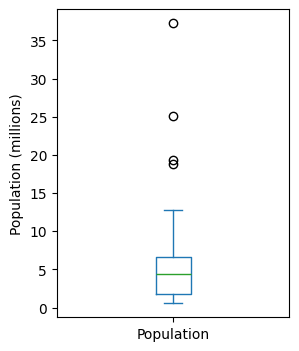

In [8]:
ax = (state['Population'] / 1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel('Population (millions)')
plt.show()

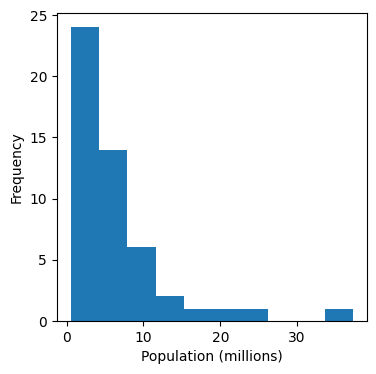

In [9]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')
plt.show()

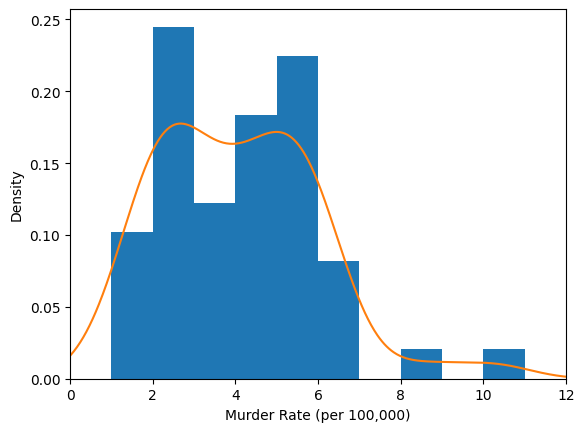

In [10]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], bins=range(1, 12))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')
plt.show()

### Interpretasi

- Boxplot populasi menunjukkan median sekitar 4-5 juta penduduk. Titik-titik di atas whisker adalah outlier, yaitu negara bagian dengan populasi jauh di atas kebanyakan negara bagian lain.
- Histogram populasi miring ke kanan (right-skewed): sebagian besar negara bagian berpopulasi kecil, sementara hanya sedikit yang sangat besar. Ini sejalan dengan mean yang lebih besar daripada median.
- Density plot murder rate memiliki dua puncak (bimodal), yang menandakan ada dua kelompok negara bagian dengan tingkat kriminalitas berbeda. Ringkasan tunggal seperti mean bisa menyembunyikan pola ini.

## 4. Data Biner dan Kategorikal

Data kategorikal berisi nilai berupa kategori, bukan angka kontinu.

- **Mode**: kategori yang paling sering muncul.
- **Proporsi / persentase**: bagian tiap kategori dari total data.
- **Bar chart**: grafik batang untuk membandingkan jumlah antar kategori.
- **Expected value**: rata-rata tertimbang dari nilai-nilai yang mungkin muncul, dengan bobot berupa probabilitasnya.

In [11]:
dfw = pd.read_csv(DATA / 'dfw_airline.csv')
print(dfw)

    Carrier      ATC   Weather  Security    Inbound
0  64263.16  84856.5  11235.42    343.15  118427.82


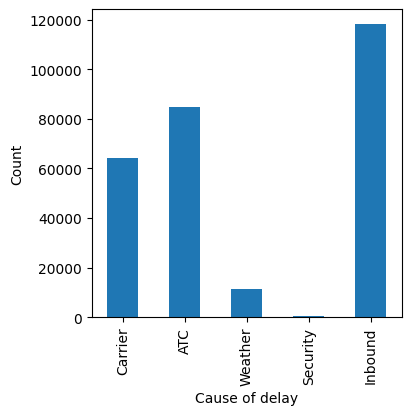

In [12]:
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')
plt.show()

### Interpretasi

- Penyebab keterlambatan terbanyak di bandara DFW adalah Inbound (±118 ribu), diikuti ATC (±85 ribu) dan Carrier (±64 ribu).
- Weather (±11 ribu) dan Security (±343) berkontribusi sangat kecil. Security hampir tidak terlihat di bar chart.
- Bar chart membantu membandingkan jumlah antar kategori dengan cepat. Dari sini kita bisa menentukan penyebab mana yang paling layak diprioritaskan untuk diperbaiki.

## 5. Korelasi

Korelasi mengukur seberapa kuat dua variabel numerik bergerak bersama.

- **Koefisien korelasi (Pearson)**: bernilai -1 sampai +1. Nilai mendekati +1 berarti keduanya naik bersama, mendekati -1 berarti berlawanan arah, mendekati 0 berarti hampir tidak ada hubungan linear.
- **Matriks korelasi**: tabel korelasi untuk semua pasangan variabel.
- **Heatmap**: matriks korelasi yang diberi warna agar pola mudah terlihat.
- **Catatan**: korelasi tidak sama dengan sebab-akibat, dan Pearson sensitif terhadap outlier.

In [13]:
sp500_px = pd.read_csv(DATA / 'sp500_data.csv.gz', index_col=0)
sp500_sym = pd.read_csv(DATA / 'sp500_sectors.csv')

In [14]:
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01',
                       sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']]
print(telecom.corr())

             T       CTL       FTR        VZ      LVLT
T     1.000000  0.474683  0.327767  0.677612  0.278626
CTL   0.474683  1.000000  0.419757  0.416604  0.286665
FTR   0.327767  0.419757  1.000000  0.287386  0.260068
VZ    0.677612  0.416604  0.287386  1.000000  0.242199
LVLT  0.278626  0.286665  0.260068  0.242199  1.000000


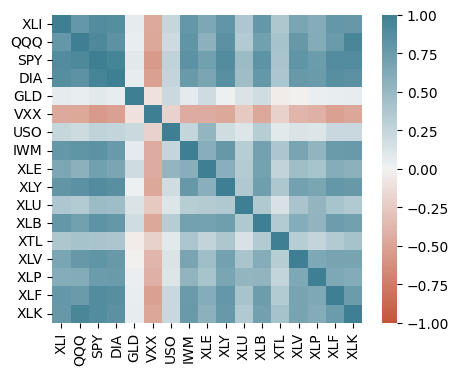

In [15]:
etfs = sp500_px.loc[sp500_px.index > '2012-07-01',
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(etfs.corr(), vmin=-1, vmax=1,
            cmap=sns.diverging_palette(20, 220, as_cmap=True), ax=ax)
plt.show()

### Interpretasi

- Di antara saham telekomunikasi, AT&T (T) dan Verizon (VZ) memiliki korelasi tertinggi (±0,68). Hal ini masuk akal karena keduanya perusahaan besar di industri yang sama sehingga harganya cenderung bergerak searah.
- Heatmap ETF menunjukkan sebagian besar ETF pasar saham berkorelasi positif kuat satu sama lain, karena bergerak mengikuti kondisi pasar secara umum.
- VXX berkorelasi negatif dengan ETF lainnya. Ini wajar karena VXX mengukur volatilitas pasar, yang biasanya naik saat pasar saham turun.
- GLD dan USO berkorelasi lemah dengan kebanyakan ETF, sehingga bisa berguna untuk diversifikasi.
- Ingat: korelasi tidak menunjukkan sebab-akibat.

## 6. Eksplorasi Dua Variabel atau Lebih

Untuk melihat hubungan antar variabel, kita pakai visualisasi khusus.

- **Scatterplot**: titik-titik yang menunjukkan hubungan dua variabel numerik. Kurang cocok untuk data sangat banyak karena titiknya menumpuk.
- **Hexbin plot**: membagi bidang menjadi sel heksagonal dan mewarnainya berdasarkan jumlah data. Cocok untuk data besar.
- **Contingency table**: tabel frekuensi untuk dua variabel kategorikal.

In [16]:
kc_tax = pd.read_csv(DATA / 'kc_tax.csv.gz')
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print(kc_tax0.shape)

(432693, 3)


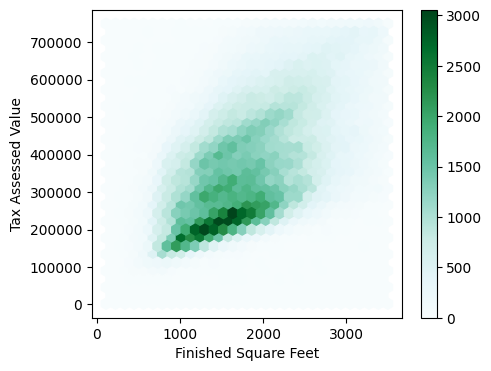

In [17]:
ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')
plt.show()

In [18]:
lc_loans = pd.read_csv(DATA / 'lc_loans.csv')
crosstab = lc_loans.pivot_table(index='grade', columns='status',
                                aggfunc=lambda x: len(x), margins=True)
print(crosstab)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961


### Interpretasi

- Hexbin menunjukkan hubungan positif antara luas rumah dan nilai pajak: rumah yang lebih luas cenderung bernilai lebih tinggi. Konsentrasi data terbesar ada pada rumah berukuran 1.000-2.000 sqft. Hexbin dipilih karena scatterplot biasa akan menumpuk pada data sebanyak ini.
- Contingency table menunjukkan distribusi pinjaman per grade dan status. Grade B, C, dan D mendominasi, sedangkan grade G paling sedikit.
- Kolom Charged Off pada grade rendah (misalnya E, F, G) terlihat lebih tinggi secara proporsi dibanding grade A. Untuk memastikannya perlu dihitung persentase per baris, bukan hanya jumlah mentah.

## Kesimpulan Bab 1

- Estimasi lokasi: mean sensitif terhadap outlier, sedangkan median dan trimmed mean lebih robust.
- Estimasi variabilitas: std sensitif terhadap outlier, sedangkan IQR dan median absolute deviation lebih tahan.
- Boxplot, histogram, dan density plot membantu melihat bentuk distribusi (skewness, outlier, bimodal).
- Data kategorikal dirangkum dengan frekuensi/proporsi dan divisualisasikan dengan bar chart.
- Korelasi mengukur hubungan linear antar variabel, tetapi tidak membuktikan sebab-akibat.
- Hexbin dan contingency table dipakai untuk mengeksplorasi hubungan dua variabel.